In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [31]:
path= 'orders_data_market_basket_analysis.csv'
data= pd.read_csv(path)
df= data.copy()

In [32]:
df.head()

,Order ID,Order Date,Product ID,Category,Product Subcategory,Sales,Quantity,Discount,Profit
0,CA-2017-152156,11/8/2017,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,CA-2017-152156,11/8/2017,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,CA-2017-138688,6/12/2017,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,US-2016-108966,10/11/2016,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,US-2016-108966,10/11/2016,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [33]:
len(df['Order ID'].unique())

5009

In [34]:
c= df.groupby('Order ID')['Product Subcategory'].apply(list)

In [35]:
te= TransactionEncoder()
basket= te.fit_transform(c)
basket= pd.DataFrame(basket, columns= te.columns_)

In [36]:
basket

,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5004,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
5005,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5006,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5007,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [37]:
fi= apriori(basket, min_support=.01, use_colnames= True)
fi

,support,itemsets
0,0.143342,(Accessories)
1,0.090038,(Appliances)
2,0.145937,(Art)
3,0.262727,(Binders)
4,0.044720,(Bookcases)
...,...,...
63,0.023358,"(Phones, Storage)"
64,0.010381,"(Tables, Phones)"
65,0.010182,"(Paper, Binders, Furnishings)"
66,0.010781,"(Paper, Phones, Binders)"


In [38]:
fi.sort_values('support', ascending= False)
# binders appears in 26% of all transactions
# paper appears in 23% of all transactions

,support,itemsets
3,0.262727,(Binders)
12,0.237772,(Paper)
9,0.175085,(Furnishings)
13,0.162507,(Phones)
14,0.155121,(Storage)
...,...,...
62,0.010781,"(Paper, Tables)"
66,0.010781,"(Paper, Phones, Binders)"
67,0.010581,"(Paper, Storage, Binders)"
64,0.010381,"(Tables, Phones)"


In [39]:
fi['itemsets']= fi['itemsets'].apply(lambda x: x if len(x)== 2 else None)

In [40]:
fi= fi.dropna()

In [41]:
top_pairs= fi.sort_values('support', ascending= False)
# binders > papers frequently bought together 5% of all transactions
# binders, phones 3.9%
top_pairs.head()

,support,itemsets
43,0.054901,"(Paper, Binders)"
44,0.039728,"(Phones, Binders)"
45,0.039728,"(Storage, Binders)"
41,0.039529,"(Binders, Furnishings)"
61,0.035536,"(Paper, Storage)"


In [42]:
top_pairs['item1'] = top_pairs['itemsets'].apply(lambda x: list(x)[0])
top_pairs['item2'] = top_pairs['itemsets'].apply(lambda x: list(x)[1])

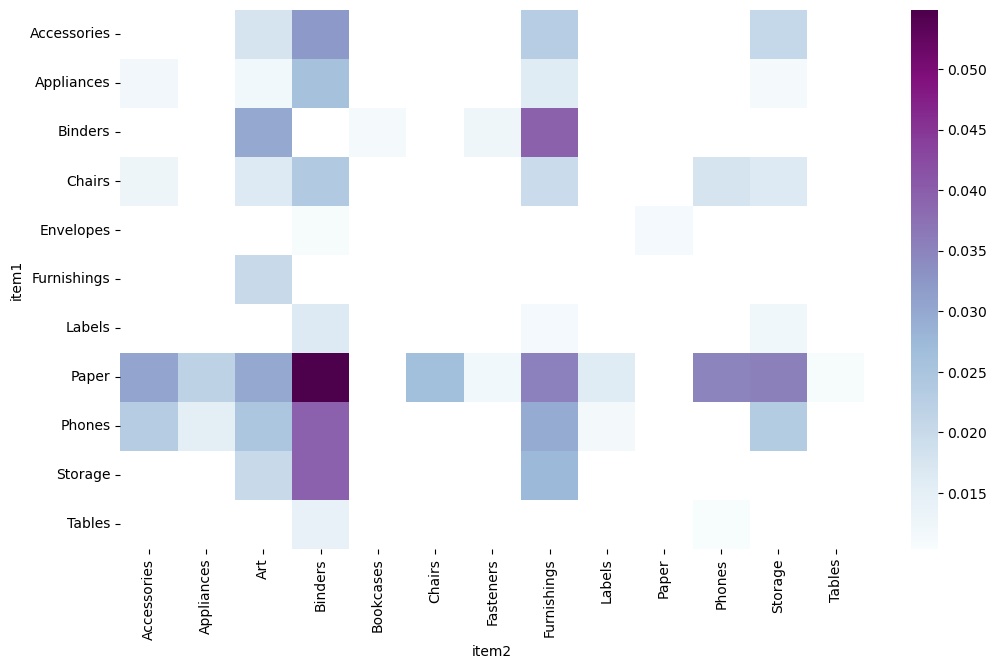

In [43]:
heatmap= pd.crosstab(top_pairs['item1'], top_pairs['item2'], values= top_pairs['support'], aggfunc= 'mean',
                     dropna= True)
plt.figure(figsize= (12 ,7))
sns.heatmap(heatmap, cmap= 'BuPu')
plt.show()

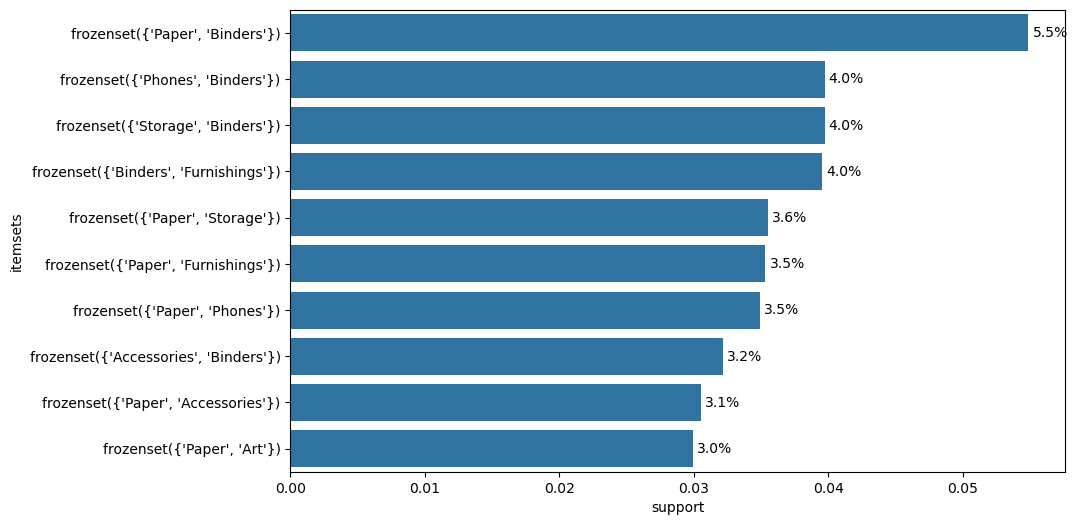

In [44]:
# Sorting and selecting top 10
fi_top10 = fi.sort_values('support', ascending=False).head(10)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=fi_top10, x='support', y='itemsets')

# Create percentage labels (e.g., 0.054 -> 5.4%)
labels = [f'{val*100:.1f}%' for val in fi_top10['support']]

# Use padding to push text to the right of the bar
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.show()

In [45]:
fi3= apriori(basket, min_support=.01, use_colnames= True)
fi3['itemsets']= fi3['itemsets'].apply(lambda x: x if len(x)== 3 else None)
fi3= fi3.dropna()
fi3.head()

,support,itemsets
65,0.010182,"(Paper, Binders, Furnishings)"
66,0.010781,"(Paper, Phones, Binders)"
67,0.010581,"(Paper, Storage, Binders)"


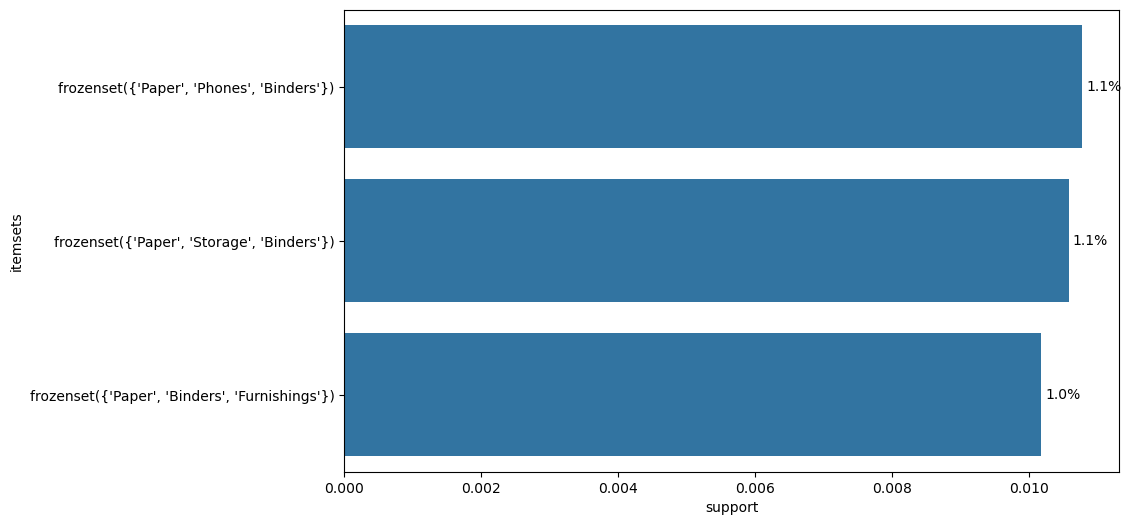

In [46]:
# Sorting and selecting top 10
fi3_top10 = fi3.sort_values('support', ascending=False).head(10)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=fi3_top10, x='support', y='itemsets')

# Create percentage labels (e.g., 0.054 -> 5.4%)
labels = [f'{val*100:.1f}%' for val in fi3_top10['support']]

# Use padding to push text to the right of the bar
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.show()

In [47]:
fi= apriori(basket, min_support=.01, use_colnames= True)

In [48]:
ar= association_rules(fi, metric= 'lift', min_threshold=1)
ar= ar.iloc[:,:7]
ar= ar.sort_values('lift', ascending= False)
ar.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
41,(Storage),"(Paper, Binders)",0.155121,0.054901,0.010581,0.068211,1.242434
36,"(Paper, Binders)",(Storage),0.054901,0.155121,0.010581,0.192727,1.242434
31,"(Paper, Binders)",(Phones),0.054901,0.162507,0.010781,0.196364,1.208336
34,(Phones),"(Paper, Binders)",0.162507,0.054901,0.010781,0.066339,1.208336
35,(Binders),"(Paper, Phones)",0.262727,0.034937,0.010781,0.041033,1.174494


### Time Series Modeling

In [49]:
df= df[['Order Date','Product Subcategory','Sales','Discount']]
df.head()

,Order Date,Product Subcategory,Sales,Discount
0,11/8/2017,Bookcases,261.9600,0.00
1,11/8/2017,Chairs,731.9400,0.00
2,6/12/2017,Labels,14.6200,0.00
3,10/11/2016,Tables,957.5775,0.45
4,10/11/2016,Storage,22.3680,0.20


In [52]:
len(df['Product Subcategory'].unique())

17